In [1]:
# ==============================
# IMPORTS
# ==============================

import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import joblib

sys.path.append("../src")

from data_preprocessing import load_data, preprocess_data
from feature_selection import select_features
from train_model import train_logistic_regression, train_xgboost
from evaluate_model import evaluate_model
from bias_analysis import gender_bias_analysis

# Color Palette (consistent)
COLOR_LOG = "#4C72B0"
COLOR_XGB = "#DD8452"
COLOR_FAIR = "#55A868"

In [2]:
# ==============================
# DATA LOADING
# ==============================

data_path = r"C:\Users\Brindha Suvarna R\Desktop\credit-risk-modeling\data\processed\feature_engineered_data.csv"
df = load_data(data_path)

print("Dataset Shape:", df.shape)
print("\nTarget Distribution:\n", df['TARGET'].value_counts())

Dataset Shape: (307511, 217)

Target Distribution:
 TARGET
0    282686
1     24825
Name: count, dtype: int64


In [3]:
# ==============================
# PREPROCESSING
# ==============================

X_train, X_test, y_train, y_test = preprocess_data(df)

X_train_fs, X_test_fs, selected_features = select_features(
    X_train, y_train, X_test, top_n=50
)

print("Selected Features:", len(selected_features))

Selected Features: 50


In [4]:
# ==============================
# BASELINE MODELS
# ==============================

log_model_base = train_logistic_regression(X_train_fs, y_train)
xgb_model_base = train_xgboost(X_train_fs, y_train)

In [5]:
print(type(log_model_base))

<class 'sklearn.pipeline.Pipeline'>


In [6]:
# ==============================
# BASELINE EVALUATION
# ==============================

log_results, y_pred_log, y_prob_log = evaluate_model(
    log_model_base, X_test_fs, y_test, threshold=0.3
)

xgb_results, y_pred_xgb, y_prob_xgb = evaluate_model(
    xgb_model_base, X_test_fs, y_test, threshold=0.2
)

print("Baseline Logistic:", log_results)
print("Baseline XGBoost:", xgb_results)

Baseline Logistic: {'accuracy': 0.348730956213518, 'precision': 0.10332353606149672, 'recall': 0.9204431017119838, 'f1_score': 0.18579123894704747, 'roc_auc': 0.7334146268564947}
Baseline XGBoost: {'accuracy': 0.25598751280425347, 'precision': 0.09528155879201555, 'recall': 0.9671701913393757, 'f1_score': 0.17347325831331395, 'roc_auc': 0.7613469549501717}


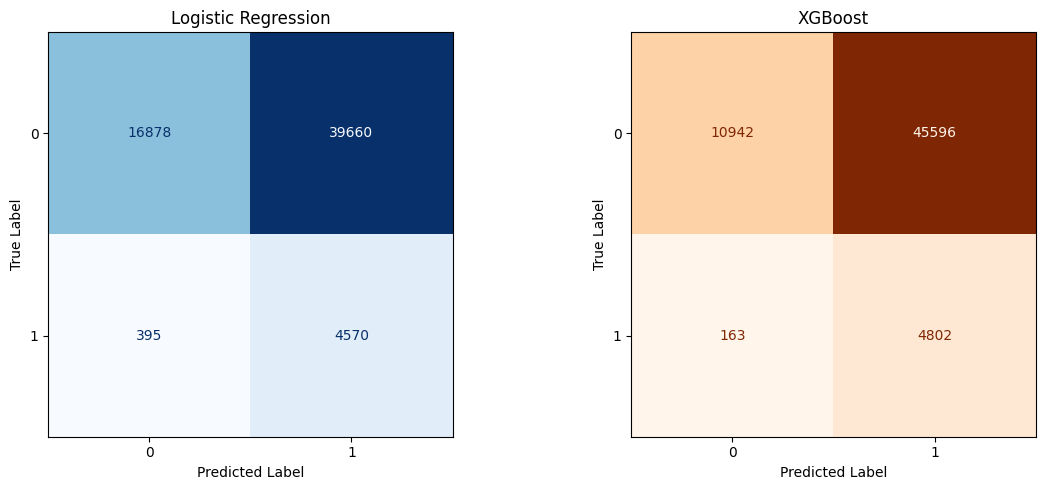

In [7]:
# ==============================
# CONFUSION MATRIX (IMPROVED)
# ==============================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Logistic Regression
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_log)
).plot(
    ax=axes[0],
    cmap="Blues",
    values_format='d',        #  FIX: removes scientific notation
    colorbar=False
)
axes[0].set_title("Logistic Regression")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

# XGBoost
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_xgb)
).plot(
    ax=axes[1],
    cmap="Oranges",
    values_format='d',        # consistent formatting
    colorbar=False
)
axes[1].set_title("XGBoost")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")

plt.tight_layout()
plt.show()

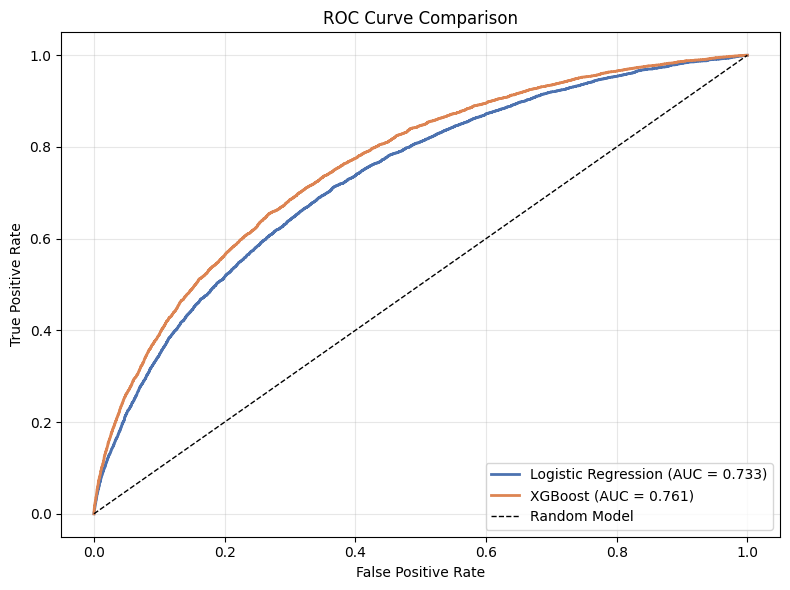

In [8]:
# ==============================
# ROC CURVE 
# ==============================

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Compute ROC
log_fpr, log_tpr, _ = roc_curve(y_test, y_prob_log)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, y_prob_xgb)

# Compute AUC
log_auc = roc_auc_score(y_test, y_prob_log)
xgb_auc = roc_auc_score(y_test, y_prob_xgb)

plt.figure(figsize=(8,6))

plt.plot(
    log_fpr, log_tpr,
    color=COLOR_LOG,
    linewidth=2,
    label=f"Logistic Regression (AUC = {log_auc:.3f})"
)

plt.plot(
    xgb_fpr, xgb_tpr,
    color=COLOR_XGB,
    linewidth=2,
    label=f"XGBoost (AUC = {xgb_auc:.3f})"
)

# Random baseline
plt.plot([0,1], [0,1], 'k--', linewidth=1, label="Random Model")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
# ==============================
# AUC CONFIDENCE INTERVAL (BOOTSTRAP) ✅ FIXED
# ==============================

import numpy as np
from sklearn.metrics import roc_auc_score

def bootstrap_auc(y_true, y_prob, n_bootstraps=1000, seed=42):

    #  CRITICAL FIX: convert to numpy
    y_true = np.array(y_true)
    y_prob = np.array(y_prob)

    rng = np.random.RandomState(seed)
    aucs = []

    for _ in range(n_bootstraps):

        indices = rng.randint(0, len(y_true), len(y_true))

        # avoid invalid sample (only one class)
        if len(np.unique(y_true[indices])) < 2:
            continue

        score = roc_auc_score(y_true[indices], y_prob[indices])
        aucs.append(score)

    aucs = np.array(aucs)

    lower = np.percentile(aucs, 2.5)
    upper = np.percentile(aucs, 97.5)

    return np.mean(aucs), lower, upper


# ==============================
# COMPUTE CI
# ==============================

log_auc_mean, log_ci_low, log_ci_high = bootstrap_auc(y_test, y_prob_log)
xgb_auc_mean, xgb_ci_low, xgb_ci_high = bootstrap_auc(y_test, y_prob_xgb)

print("\nAUC with 95% Confidence Interval:")
print(f"Logistic Regression: {log_auc_mean:.3f} ({log_ci_low:.3f}, {log_ci_high:.3f})")
print(f"XGBoost           : {xgb_auc_mean:.3f} ({xgb_ci_low:.3f}, {xgb_ci_high:.3f})")


AUC with 95% Confidence Interval:
Logistic Regression: 0.733 (0.726, 0.741)
XGBoost           : 0.761 (0.754, 0.768)


In [10]:
# ==============================
# DELONG TEST (STATISTICAL SIGNIFICANCE)
# ==============================

import numpy as np
from scipy import stats


def compute_midrank(x):
    """Computes midranks for DeLong test"""
    sorted_idx = np.argsort(x)
    sorted_x = x[sorted_idx]
    
    midranks = np.zeros(len(x))
    i = 0
    
    while i < len(x):
        j = i
        while j < len(x) and sorted_x[j] == sorted_x[i]:
            j += 1
        
        midrank = 0.5 * (i + j - 1)
        for k in range(i, j):
            midranks[k] = midrank
        
        i = j
    
    result = np.empty(len(x))
    result[sorted_idx] = midranks + 1  # +1 for rank
    
    return result


def fast_delong(y_true, y_prob):
    """Fast DeLong implementation"""
    
    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    
    pos = y_prob[y_true == 1]
    neg = y_prob[y_true == 0]
    
    m = len(pos)
    n = len(neg)
    
    all_scores = np.concatenate([pos, neg])
    ranks = compute_midrank(all_scores)
    
    pos_ranks = ranks[:m]
    neg_ranks = ranks[m:]
    
    auc = (np.sum(pos_ranks) - m * (m + 1) / 2) / (m * n)
    
    v01 = (pos_ranks - np.arange(1, m + 1)) / n
    v10 = 1 - (neg_ranks - np.arange(1, n + 1)) / m
    
    sx = np.var(v01)
    sy = np.var(v10)
    
    return auc, sx / m + sy / n


def delong_test(y_true, prob1, prob2):
    """Compare two models using DeLong test"""
    
    auc1, var1 = fast_delong(y_true, prob1)
    auc2, var2 = fast_delong(y_true, prob2)
    
    diff = auc1 - auc2
    var = var1 + var2
    
    z = diff / np.sqrt(var)
    p_value = 2 * (1 - stats.norm.cdf(abs(z)))
    
    return auc1, auc2, z, p_value


# ==============================
# RUN TEST
# ==============================

auc_log, auc_xgb, z_stat, p_val = delong_test(
    y_test,
    y_prob_log,
    y_prob_xgb
)

print("\nDeLong Test Results:")
print(f"Logistic AUC : {auc_log:.3f}")
print(f"XGBoost AUC  : {auc_xgb:.3f}")
print(f"Z-statistic  : {z_stat:.3f}")
print(f"P-value      : {p_val:.6f}")


DeLong Test Results:
Logistic AUC : 0.733
XGBoost AUC  : 0.761
Z-statistic  : -0.960
P-value      : 0.336932


In [11]:
# ==============================
# FINAL RESULTS TABLE (RESEARCH READY)
# ==============================

results_table = pd.DataFrame({
    "Model": ["Logistic Regression", "XGBoost"],
    "AUC": [auc_log, auc_xgb],
    "CI Lower": [log_ci_low, xgb_ci_low],
    "CI Upper": [log_ci_high, xgb_ci_high]
})

# Add formatted column
results_table["AUC (95% CI)"] = results_table.apply(
    lambda x: f"{x['AUC']:.3f} ({x['CI Lower']:.3f}, {x['CI Upper']:.3f})",
    axis=1
)

results_table = results_table[["Model", "AUC (95% CI)"]]

print("\nFinal Results Table:")
print(results_table)


Final Results Table:
                 Model          AUC (95% CI)
0  Logistic Regression  0.733 (0.726, 0.741)
1              XGBoost  0.761 (0.754, 0.768)


In [12]:
print("\nDeLong Test Summary:")
print(f"Z = {z_stat:.3f}, p-value = {p_val:.6f}")


DeLong Test Summary:
Z = -0.960, p-value = 0.336932


In [13]:
print(min(y_prob_log), max(y_prob_log))

1.4186989779517865e-11 0.965134143254982


In [14]:
# ==============================
# CREATE GROUPS FOR FAIRNESS ANALYSIS
# ==============================

import pandas as pd

# Income Groups (Low / Medium / High)
X_test["income_group"] = pd.qcut(
    X_test["AMT_INCOME_TOTAL"],
    q=3,
    labels=["Low", "Medium", "High"]
)

# Age Groups (Young / Middle / Senior)
X_test["age_group"] = pd.cut(
    X_test["AGE_YEARS"],
    bins=[20, 35, 50, 70],
    labels=["Young", "Middle", "Senior"]
)

C:\Users\Brindha Suvarna R\AppData\Local\Temp\ipykernel_16184\2200062985.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_test["income_group"] = pd.qcut(
C:\Users\Brindha Suvarna R\AppData\Local\Temp\ipykernel_16184\2200062985.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_test["age_group"] = pd.cut(


In [15]:
print(X_test[["income_group", "age_group"]].head())

       income_group age_group
256571       Medium    Middle
191493          Low    Middle
103497       Medium    Senior
130646         High     Young
211898       Medium    Middle


In [16]:
# ==============================
# CREATE ADDITIONAL GROUPS (AGE + INCOME)
# ==============================

X_test = X_test.copy()

# Age groups
X_test["AGE_GROUP"] = pd.cut(
    X_test["AGE_YEARS"],
    bins=[20, 30, 40, 50, 60, 100],
    labels=["20-30", "30-40", "40-50", "50-60", "60+"]
)

# Income groups
X_test["INCOME_GROUP"] = pd.qcut(
    X_test["AMT_INCOME_TOTAL"],
    q=4,
    labels=["Low", "Mid-Low", "Mid-High", "High"]
)

In [17]:
# ==============================
# CORRECT FAIRNESS FUNCTION
# ==============================
from sklearn.metrics import confusion_matrix

def group_bias_analysis(model, X_full, X_model, y_test, group_col, threshold=0.3):

    results = []

    # Ensure index alignment
    X_full = X_full.reset_index(drop=True)
    X_model = X_model.reset_index(drop=True)
    y_test = y_test.reset_index(drop=True)

    for group in X_full[group_col].dropna().unique():

        idx = X_full[X_full[group_col] == group].index

        if len(idx) == 0:
            continue

        X_group = X_model.loc[idx]
        y_true = y_test.loc[idx]

        # Predictions
        y_prob = model.predict_proba(X_group)[:, 1]
        y_pred = (y_prob >= threshold).astype(int)

        # Confusion matrix
        tn, fp, fn, tp = confusion_matrix(
            y_true, y_pred, labels=[0, 1]
        ).ravel()

        # Fairness metrics
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        positive_rate = (tp + fp) / len(y_true)

        results.append({
            "group": str(group),
            "samples": len(idx),
            "tpr": tpr,
            "fpr": fpr,
            "positive_rate": positive_rate
        })

    return pd.DataFrame(results)

In [18]:
# ==============================
# BIAS BEFORE MITIGATION
# ==============================

print("\n========== BEFORE MITIGATION ==========\n")

# --- GENDER (already correct function) ---
log_gender_before = gender_bias_analysis(
    log_model_base, X_test, X_test_fs, y_test
)

xgb_gender_before = gender_bias_analysis(
    xgb_model_base, X_test, X_test_fs, y_test
)

# --- AGE ---
log_age_before = group_bias_analysis(
    log_model_base, X_test, X_test_fs, y_test,
    group_col="AGE_GROUP", threshold=0.3
)

xgb_age_before = group_bias_analysis(
    xgb_model_base, X_test, X_test_fs, y_test,
    group_col="AGE_GROUP", threshold=0.2
)

# --- INCOME ---
log_income_before = group_bias_analysis(
    log_model_base, X_test, X_test_fs, y_test,
    group_col="INCOME_GROUP", threshold=0.3
)

xgb_income_before = group_bias_analysis(
    xgb_model_base, X_test, X_test_fs, y_test,
    group_col="INCOME_GROUP", threshold=0.2
)

# --- PRINT ---
print("Logistic Gender:\n", log_gender_before)
print("\nXGBoost Gender:\n", xgb_gender_before)

print("\nLogistic Age:\n", log_age_before)
print("\nXGBoost Age:\n", xgb_age_before)

print("\nLogistic Income:\n", log_income_before)
print("\nXGBoost Income:\n", xgb_income_before)


========== BEFORE MITIGATION ==========

Logistic Gender:
                group  samples  accuracy  positive_rate  TPR (recall)       FPR
0    CODE_GENDER_M=0    40563  0.173730       0.892538      0.973907  0.886421
1    CODE_GENDER_M=1    20940  0.184097       0.915473      0.989667  0.907076
2  CODE_GENDER_XNA=0    61501  0.177265       0.900343      0.980665  0.893289
3  CODE_GENDER_XNA=1        2  0.000000       1.000000      0.000000  1.000000

XGBoost Gender:
                group  samples  accuracy  positive_rate  TPR (recall)       FPR
0    CODE_GENDER_M=0    40563  0.263220       0.800927      0.958745  0.789064
1    CODE_GENDER_M=1    20940  0.241977       0.855301      0.978394  0.841369
2  CODE_GENDER_XNA=0    61501  0.255996       0.819434      0.967170  0.806460
3  CODE_GENDER_XNA=1        2  0.000000       1.000000      0.000000  1.000000

Logistic Age:
    group  samples       tpr       fpr  positive_rate
0  30-40    16490  0.950602  0.760445       0.778654
1  40-50  

In [19]:
# ==============================
# BIAS MITIGATION (NO CHANGE)
# ==============================

import numpy as np

def compute_sample_weights(X_full, y):

    X_full = X_full.reset_index(drop=True)
    y = y.reset_index(drop=True)

    weights = np.ones(len(y))

    gender_cols = [c for c in X_full.columns if "CODE_GENDER" in c]

    for col in gender_cols:
        mask = X_full[col] == 1
        group_size = mask.sum()

        if group_size > 0:
            weights[mask] = len(y) / (group_size * len(gender_cols))

    return weights


sample_weights = compute_sample_weights(X_train, y_train)

In [20]:
# ==============================|
# FAIR MODELS
# ==============================

log_model_fair = train_logistic_regression(X_train_fs, y_train, sample_weights)
xgb_model_fair = train_xgboost(X_train_fs, y_train, sample_weights)

log_fair_results, _, _ = evaluate_model(log_model_fair, X_test_fs, y_test, threshold=0.3)
xgb_fair_results, _, _ = evaluate_model(xgb_model_fair, X_test_fs, y_test, threshold=0.2)

In [21]:
# ==============================
# BIAS AFTER MITIGATION
# ==============================

print("\n========== AFTER MITIGATION ==========\n")

# --- GENDER ---
log_gender_after = gender_bias_analysis(
    log_model_fair, X_test, X_test_fs, y_test
)

xgb_gender_after = gender_bias_analysis(
    xgb_model_fair, X_test, X_test_fs, y_test
)

# --- AGE ---
log_age_after = group_bias_analysis(
    log_model_fair, X_test, X_test_fs, y_test,
    group_col="AGE_GROUP", threshold=0.3
)

xgb_age_after = group_bias_analysis(
    xgb_model_fair, X_test, X_test_fs, y_test,
    group_col="AGE_GROUP", threshold=0.2
)

# --- INCOME ---
log_income_after = group_bias_analysis(
    log_model_fair, X_test, X_test_fs, y_test,
    group_col="INCOME_GROUP", threshold=0.3
)

xgb_income_after = group_bias_analysis(
    xgb_model_fair, X_test, X_test_fs, y_test,
    group_col="INCOME_GROUP", threshold=0.2
)

# --- PRINT ---
print("Logistic Gender:\n", log_gender_after)
print("\nXGBoost Gender:\n", xgb_gender_after)

print("\nLogistic Age:\n", log_age_after)
print("\nXGBoost Age:\n", xgb_age_after)

print("\nLogistic Income:\n", log_income_after)
print("\nXGBoost Income:\n", xgb_income_after)


========== AFTER MITIGATION ==========

Logistic Gender:
                group  samples  accuracy  positive_rate  TPR (recall)       FPR
0    CODE_GENDER_M=0    40563  0.155388       0.910978      0.974612  0.906195
1    CODE_GENDER_M=1    20940  0.173161       0.925931      0.987318  0.918984
2  CODE_GENDER_XNA=0    61501  0.161445       0.916066      0.980060  0.910446
3  CODE_GENDER_XNA=1        2  0.000000       1.000000      0.000000  1.000000

XGBoost Gender:
                group  samples  accuracy  positive_rate  TPR (recall)       FPR
0    CODE_GENDER_M=0    40563  0.254123       0.809827      0.957334  0.798738
1    CODE_GENDER_M=1    20940  0.238061       0.859599      0.980272  0.845941
2  CODE_GENDER_XNA=0    61501  0.248663       0.826767      0.967170  0.814437
3  CODE_GENDER_XNA=1        2  0.000000       1.000000      0.000000  1.000000

Logistic Age:
    group  samples       tpr       fpr  positive_rate
0  30-40    16490  0.946802  0.771310       0.788114
1  40-50   

In [22]:
# ==============================
# STANDARDIZE GENDER COLUMNS
# ==============================

def fix_gender_df(df):
    df = df.copy()

    rename_map = {
        "TPR (recall)": "tpr",
        "FPR": "fpr"
    }

    df = df.rename(columns=rename_map)

    return df


# Apply fix
log_gender_before = fix_gender_df(log_gender_before)
log_gender_after  = fix_gender_df(log_gender_after)

xgb_gender_before = fix_gender_df(xgb_gender_before)
xgb_gender_after  = fix_gender_df(xgb_gender_after)

In [34]:
# ==============================
# VISUALIZATION (FAIRNESS CORRECT)
# ==============================

def plot_bias(before, after, metric, title):

    df = pd.DataFrame({
        "group": before["group"],
        "Before": before[metric],
        "After": after[metric]
    })

    df.plot(
        kind="bar",
        x="group",
        figsize=(8,5),
        color=[COLOR_LOG, COLOR_FAIR]
    )

    plt.title(f"{title} ({metric.upper()})")
    plt.ylabel(metric.upper())
    plt.xticks(rotation=30)
    plt.tight_layout()

   # Save to project root reports/results, not inside notebooks/
    project_root = os.path.dirname(os.getcwd())
    save_dir = os.path.join(project_root, "reports", "results")
    os.makedirs(save_dir, exist_ok=True)
    filename = title.lower().replace(" - ", "_").replace(" ", "_")
    plt.savefig(os.path.join(save_dir, f"{filename}_{metric}.png"), dpi=150, bbox_inches='tight')
    plt.show()

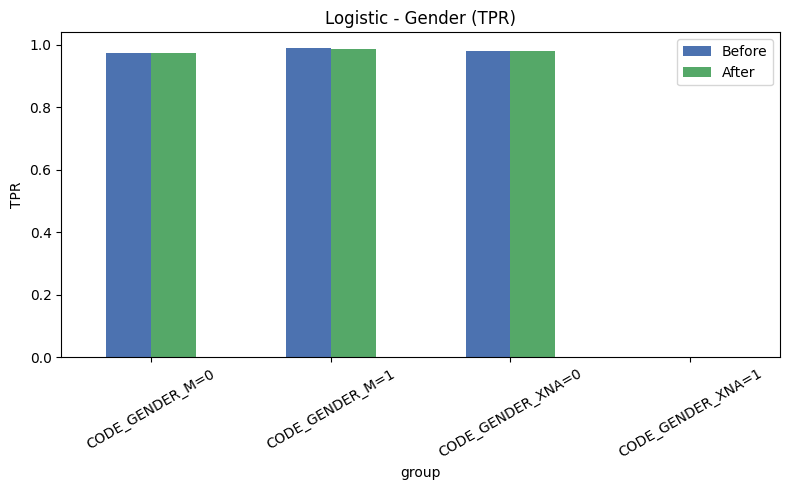

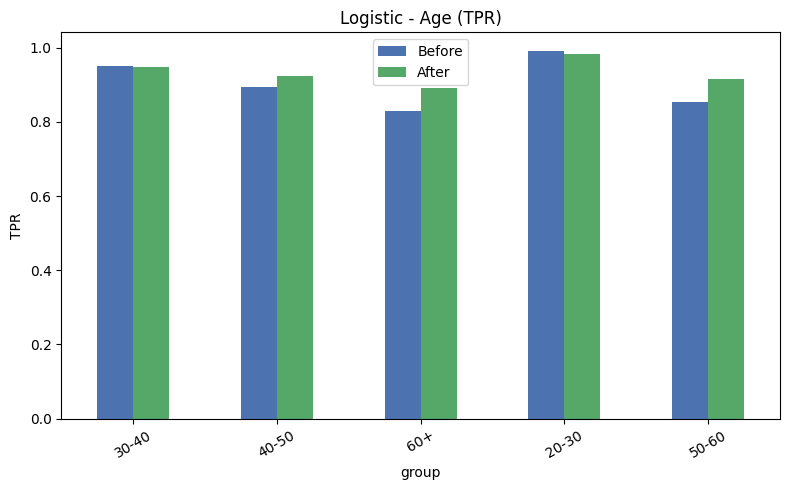

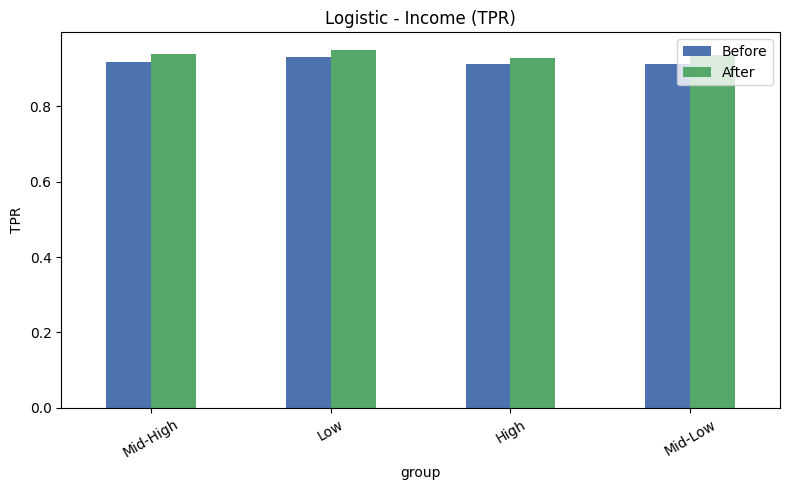

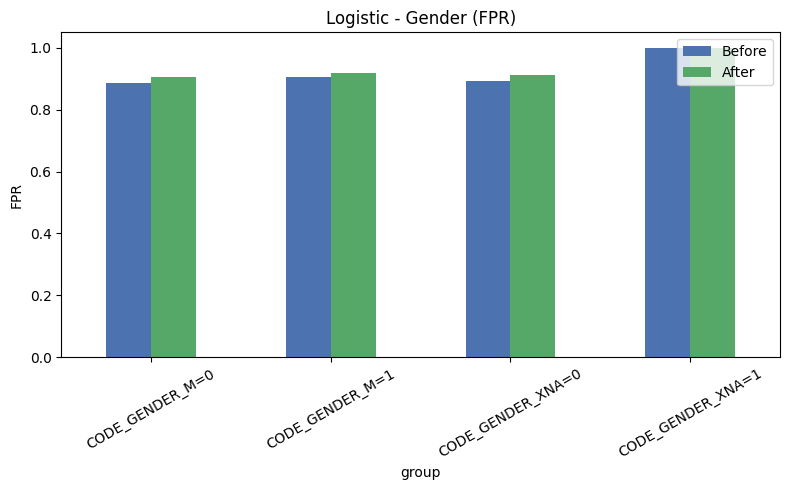

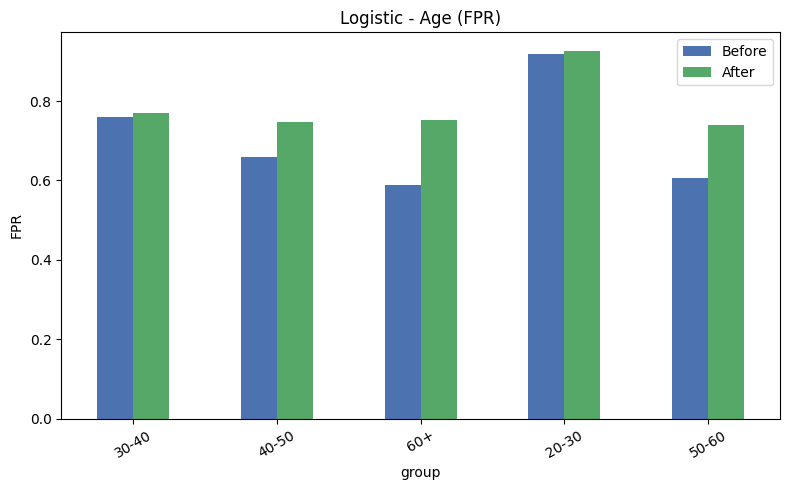

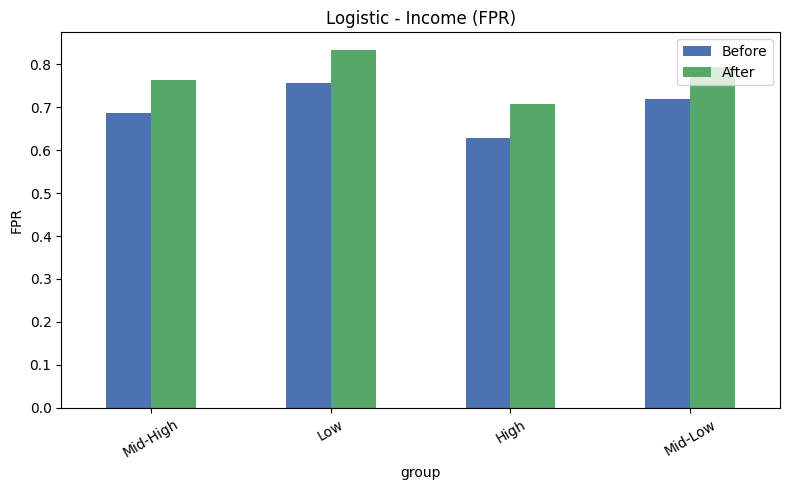

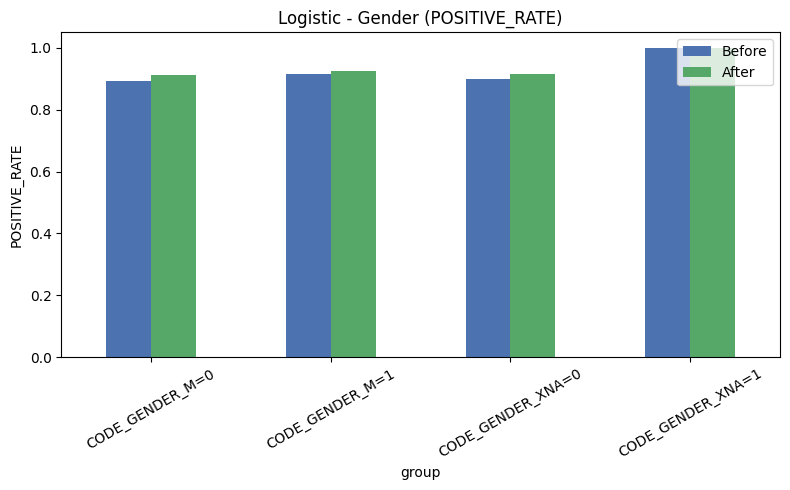

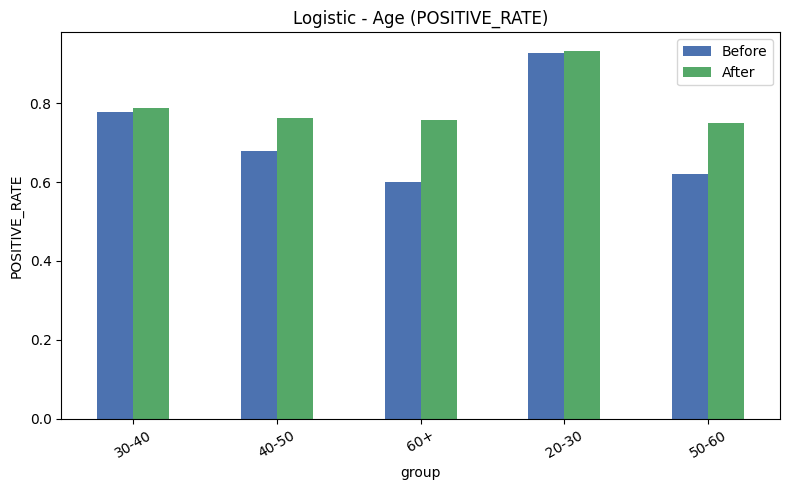

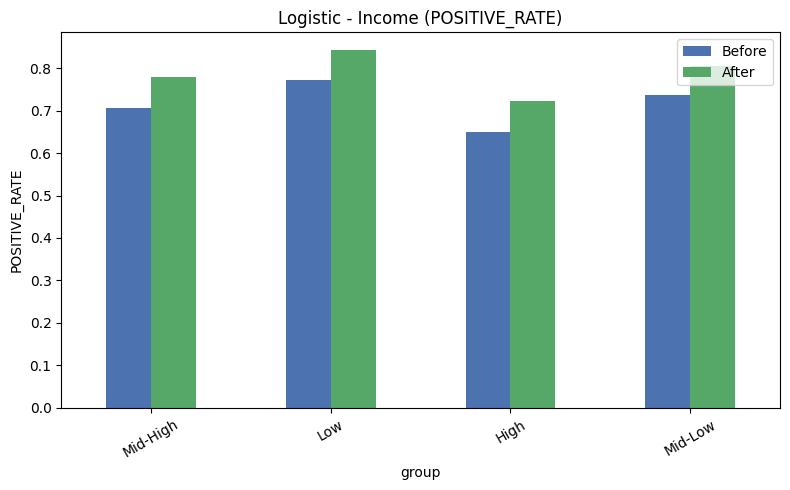

In [35]:
# TPR
plot_bias(log_gender_before, log_gender_after, "tpr", "Logistic - Gender")
plot_bias(log_age_before, log_age_after, "tpr", "Logistic - Age")
plot_bias(log_income_before, log_income_after, "tpr", "Logistic - Income")

# FPR
plot_bias(log_gender_before, log_gender_after, "fpr", "Logistic - Gender")
plot_bias(log_age_before, log_age_after, "fpr", "Logistic - Age")
plot_bias(log_income_before, log_income_after, "fpr", "Logistic - Income")

# Demographic Parity
plot_bias(log_gender_before, log_gender_after, "positive_rate", "Logistic - Gender")
plot_bias(log_age_before, log_age_after, "positive_rate", "Logistic - Age")
plot_bias(log_income_before, log_income_after, "positive_rate", "Logistic - Income")

In [25]:
def fairness_gap(df, metric):
    return df[metric].max() - df[metric].min()

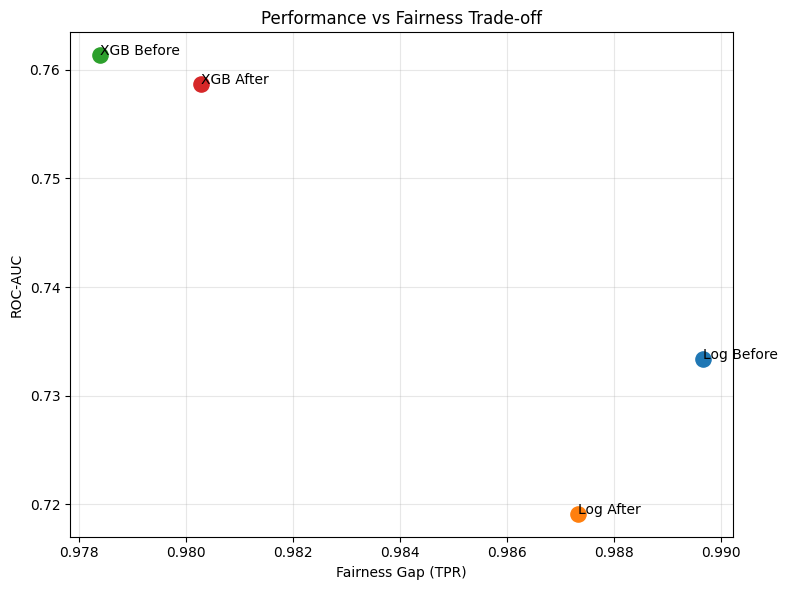

In [36]:
# ==============================
# PERFORMANCE vs FAIRNESS
# ==============================

from streamlit import metric, title


performance = [
    log_results["roc_auc"],
    log_fair_results["roc_auc"],
    xgb_results["roc_auc"],
    xgb_fair_results["roc_auc"]
]

fairness = [
    fairness_gap(log_gender_before, "tpr"),
    fairness_gap(log_gender_after, "tpr"),
    fairness_gap(xgb_gender_before, "tpr"),
    fairness_gap(xgb_gender_after, "tpr")
]

labels = ["Log Before", "Log After", "XGB Before", "XGB After"]

plt.figure(figsize=(8,6))

for i in range(len(labels)):
    plt.scatter(fairness[i], performance[i], s=120)
    plt.text(fairness[i], performance[i], labels[i])

plt.xlabel("Fairness Gap (TPR)")
plt.ylabel("ROC-AUC")
plt.title("Performance vs Fairness Trade-off")

plt.grid(alpha=0.3)
plt.tight_layout()

save_dir = r"C:\Users\Brindha Suvarna R\Desktop\credit-risk-modeling\reports\results"
os.makedirs(save_dir, exist_ok=True)
plt.savefig(os.path.join(save_dir, "performance_vs_fairness.png"), dpi=150, bbox_inches='tight')

plt.show()


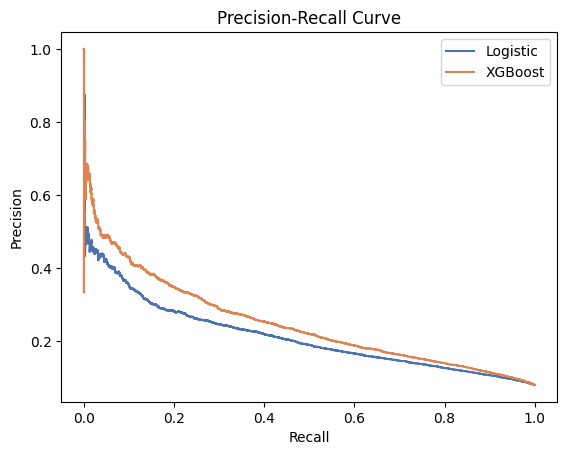

In [37]:
# ==============================
# PRECISION-RECALL CURVE
# ==============================

from sklearn.metrics import precision_recall_curve

log_p, log_r, _ = precision_recall_curve(y_test, y_prob_log)
xgb_p, xgb_r, _ = precision_recall_curve(y_test, y_prob_xgb)

plt.plot(log_r, log_p, color=COLOR_LOG, label="Logistic")
plt.plot(xgb_r, xgb_p, color=COLOR_XGB, label="XGBoost")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()

# Save
save_dir = r"C:\Users\Brindha Suvarna R\Desktop\credit-risk-modeling\reports\results"
os.makedirs(save_dir, exist_ok=True)
plt.savefig(os.path.join(save_dir, "precision_recall_curve.png"), dpi=150, bbox_inches='tight')

plt.show()


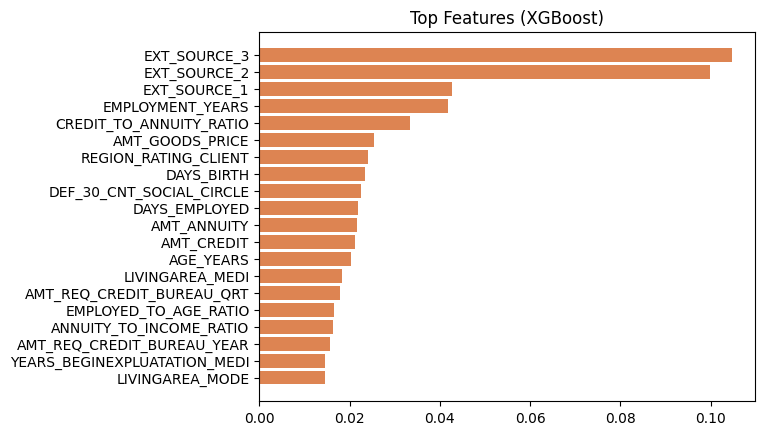

In [38]:
# ==============================
# FEATURE IMPORTANCE
# ==============================

importances = xgb_model_base.feature_importances_

fi = pd.DataFrame({
    "feature": X_train_fs.columns,
    "importance": importances
}).sort_values(by="importance", ascending=False).head(20)

plt.barh(fi["feature"], fi["importance"], color=COLOR_XGB)
plt.gca().invert_yaxis()
plt.title("Top Features (XGBoost)")

# Save
save_dir = r"C:\Users\Brindha Suvarna R\Desktop\credit-risk-modeling\reports\results"
os.makedirs(save_dir, exist_ok=True)
plt.savefig(os.path.join(save_dir, "top_features_xgboost.png"), dpi=150, bbox_inches='tight')

plt.show()
plt.show()

In [29]:
log_model_base
log_model_base.named_steps
type(log_model_base)

sklearn.pipeline.Pipeline

In [30]:
# ==============================
# LOGISTIC COEFFICIENTS (FIXED)
# ==============================

# Step 1: check pipeline steps (run once)
print(log_model_base.named_steps)

# Step 2: get the correct model name from output above
# Replace 'classifier' with actual key if different
log_model = log_model_base.named_steps['classifier']

# Step 3: extract coefficients
coef = log_model.coef_[0]

# Step 4: create dataframe
coef_df = pd.DataFrame({
    "feature": X_train_fs.columns,
    "coef": coef
})

# Step 5: sort and display top 20
coef_df = coef_df.sort_values(by="coef", ascending=False).head(20)

coef_df

{'scaler': StandardScaler(), 'classifier': LogisticRegression(class_weight='balanced', max_iter=3000)}


,feature,coef
14,AMT_CREDIT,1.051751
37,BASEMENTAREA_MEDI,0.306514
32,APARTMENTS_AVG,0.181700
24,OBS_30_CNT_SOCIAL_CIRCLE,0.176171
27,LIVINGAREA_AVG,0.170655
45,ENTRANCES_MEDI,0.128131
7,ANNUITY_TO_INCOME_RATIO,0.097936
22,AMT_REQ_CREDIT_BUREAU_YEAR,0.093403
48,DEF_30_CNT_SOCIAL_CIRCLE,0.078722
10,AMT_ANNUITY,0.073836


100%|===================| 61450/61503 [07:22<00:00]        

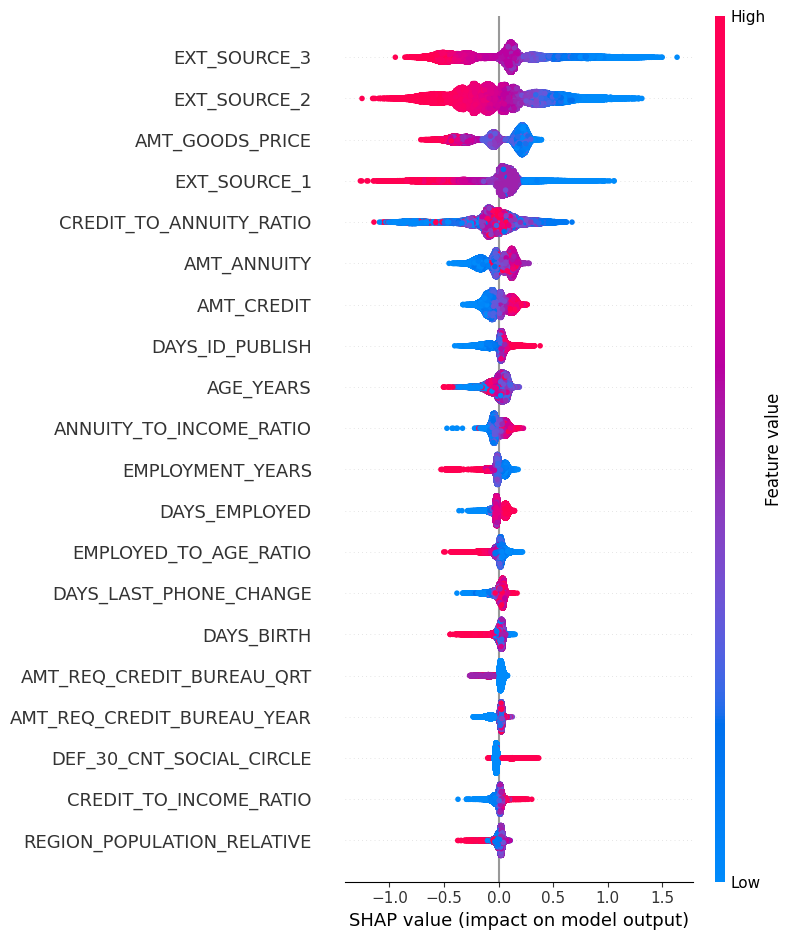

In [31]:
# ==============================
# SHAP
# ==============================

explainer = shap.Explainer(xgb_model_base, X_train_fs)
shap_values = explainer(X_test_fs)

shap.summary_plot(shap_values, X_test_fs)

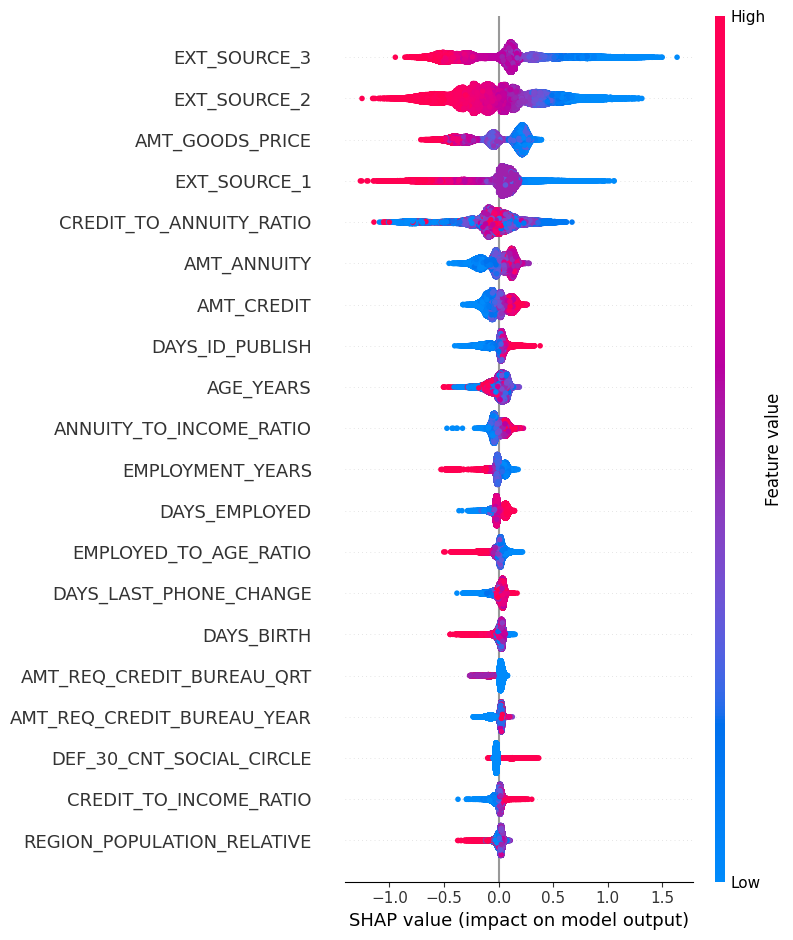

In [39]:
save_dir = r"C:\Users\Brindha Suvarna R\Desktop\credit-risk-modeling\reports\results"
os.makedirs(save_dir, exist_ok=True)

# show=False prevents display, then save manually
shap.summary_plot(shap_values, X_test_fs, show=False)
plt.savefig(os.path.join(save_dir, "shap_beeswarm.png"), dpi=150, bbox_inches='tight')
plt.show()

In [38]:
# ==============================
# SAVE MODEL
# ==============================

joblib.dump(xgb_model_base, "../models/xgb_model.pkl")
joblib.dump(X_train_fs.columns.tolist(), "../models/feature_columns.pkl")

['../models/feature_columns.pkl']